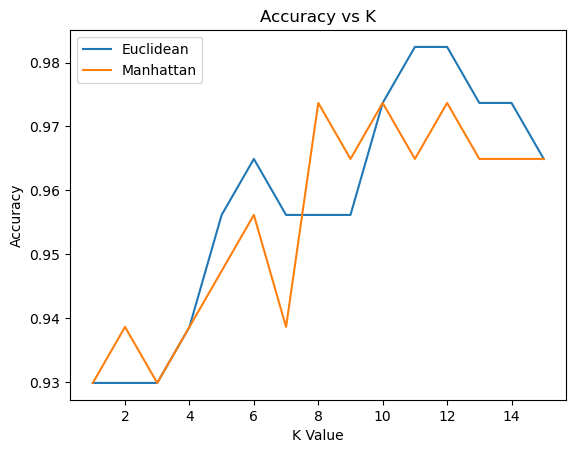

     K  Euclidean Accuracy  Manhattan Accuracy
0    1            0.929825            0.929825
1    2            0.929825            0.938596
2    3            0.929825            0.929825
3    4            0.938596            0.938596
4    5            0.956140            0.947368
5    6            0.964912            0.956140
6    7            0.956140            0.938596
7    8            0.956140            0.973684
8    9            0.956140            0.964912
9   10            0.973684            0.973684
10  11            0.982456            0.964912
11  12            0.982456            0.973684
12  13            0.973684            0.964912
13  14            0.973684            0.964912
14  15            0.964912            0.964912


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Step 1: Load dataset
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Step 2: Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

k_values = range(1,16)

accuracy_euclidean = []
accuracy_manhattan = []

# Step 3: Train model for different K values
for k in k_values:
    
    # Euclidean distance
    knn_eu = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn_eu.fit(X_train, y_train)
    pred_eu = knn_eu.predict(X_test)
    accuracy_euclidean.append(accuracy_score(y_test, pred_eu))
    
    # Manhattan distance
    knn_man = KNeighborsClassifier(n_neighbors=k, metric='manhattan')
    knn_man.fit(X_train, y_train)
    pred_man = knn_man.predict(X_test)
    accuracy_manhattan.append(accuracy_score(y_test, pred_man))

# Step 4: Plot Accuracy vs K
plt.figure()
plt.plot(k_values, accuracy_euclidean, label="Euclidean")
plt.plot(k_values, accuracy_manhattan, label="Manhattan")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.legend()
plt.show()

# Step 5: Compare results
results = pd.DataFrame({
    "K": list(k_values),
    "Euclidean Accuracy": accuracy_euclidean,
    "Manhattan Accuracy": accuracy_manhattan
})

print(results)